## 1번

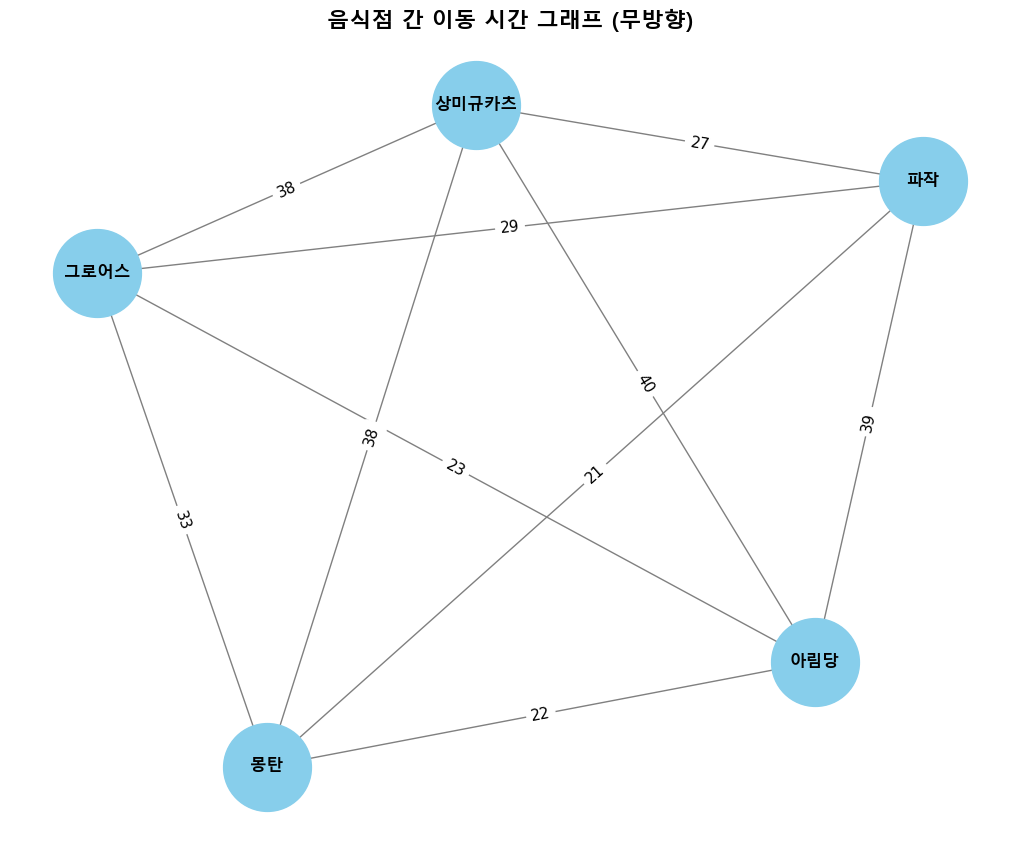

In [3]:
import matplotlib.pyplot as plt
import networkx as nx

# 한글 폰트 설정 
# (주의: 사용하시는 운영체제에 따라 폰트 이름을 변경해주세요. 
# 윈도우: 'Malgun Gothic', 맥: 'AppleGothic')
plt.rc('font', family='Malgun Gothic') 

# 음식점 리스트 (노드)
restaurants = ["상미규카츠", "파작", "몽탄", "그로어스", "아림당"]

# 이동 시간 정보 (인접 행렬)
# 행(row): 출발지, 열(column): 도착지
matrix = [
    [0, 23, 42, 39, 43],
    [32, 0, 22, 31, 44],
    [35, 20, 0, 37, 25],
    [38, 27, 30, 0, 24],
    [38, 34, 19, 22, 0]
]

# 무방향 그래프(Undirected Graph) 생성
G = nx.Graph()

# 그래프에 노드 추가
for node in restaurants:
    G.add_node(node)

# 그래프에 가중치 간선 추가
# 무방향이므로 (i -> j)와 (j -> i) 시간의 평균값을 가중치로 사용
for i in range(len(restaurants)):
    for j in range(i + 1, len(restaurants)):
        weight = (matrix[i][j] + matrix[j][i]) // 2
        G.add_edge(restaurants[i], restaurants[j], weight=weight)

# 그래프 시각화 설정
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)  # 일정하게 그려지도록 시드(seed) 고정

# 노드 및 간선 그리기
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=4000, 
        font_family='Malgun Gothic', font_size=12, font_weight='bold', edge_color='gray')

# 간선의 가중치(시간) 라벨 그리기
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=11)

plt.title('음식점 간 이동 시간 그래프 (무방향)', fontsize=16, fontweight='bold')
plt.show()

## 2번

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.animation import FuncAnimation

# 1. 폰트 설정 (환경에 맞게 변경: 윈도우 'Malgun Gothic', 맥 'AppleGothic')
plt.rc('font', family='Malgun Gothic') 

# 2. 음식점 및 그래프 데이터 설정
restaurants = ["상미규카츠", "파작", "몽탄", "그로어스", "아림당"]
matrix = [
    [0, 23, 42, 39, 43],
    [32, 0, 22, 31, 44],
    [35, 20, 0, 37, 25],
    [38, 27, 30, 0, 24],
    [38, 34, 19, 22, 0]
]

G = nx.Graph()
for node in restaurants:
    G.add_node(node)

for i in range(len(restaurants)):
    for j in range(i + 1, len(restaurants)):
        weight = (matrix[i][j] + matrix[j][i]) // 2
        G.add_edge(restaurants[i], restaurants[j], weight=weight)

pos = nx.spring_layout(G, seed=42)

# 3. DFS 탐색 과정 기록 (상태 저장)
frames = []
visited = set()
visited_order = []
traversed_edges = []

def dfs(u, parent=None):
    visited.add(u)
    visited_order.append(u)
    if parent is not None:
        traversed_edges.append((parent, u))
    
    frames.append({
        'visited': list(visited_order),
        'current': u,
        'edges': list(traversed_edges)
    })
    
    neighbors = sorted(list(G.neighbors(u)))
    for v in neighbors:
        if v not in visited:
            dfs(v, u)
            # 백트래킹(되돌아가기) 상태도 저장
            frames.append({
                'visited': list(visited_order),
                'current': u,
                'edges': list(traversed_edges)
            })

dfs(restaurants[0])

# 4. 애니메이션 설정 및 화면 출력
fig, ax = plt.subplots(figsize=(10, 8))

def update(frame_idx):
    ax.clear()
    state = frames[frame_idx]
    
    # 기본 그래프 바탕 (회색)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color='lightgray', node_size=4000)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='lightgray')
    nx.draw_networkx_labels(G, pos, ax=ax, font_family='Malgun Gothic', font_size=12, font_weight='bold')
    
    # 방문 완료한 노드 (하늘색)
    if state['visited']:
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=state['visited'], node_color='skyblue', node_size=4000)
    
    # 현재 탐색 중인 노드 (주황색)
    if state['current']:
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=[state['current']], node_color='orange', node_size=4000)
        
    # 지나온 간선 (파란색)
    if state['edges']:
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=state['edges'], edge_color='blue', width=2.5)
        
    # 가중치 텍스트 표시
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=11, ax=ax)
    
    ax.set_title(f"DFS 탐색 과정 (현재 방문: {state['current']})", fontsize=16, fontweight='bold')

# interval=1000 은 1초(1000ms) 단위로 프레임이 넘어감을 의미합니다.
# 속도를 조절하고 싶으시다면 interval 값을 변경해주세요 (예: 500 = 0.5초)
ani = FuncAnimation(fig, update, frames=len(frames), interval=1000, repeat=False)

# 화면에 출력
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# 1. 로컬 환경 한글 폰트 설정
# 윈도우 사용자: 'Malgun Gothic' / 맥 사용자: 'AppleGothic'
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 2. 음식점 및 그래프 데이터 설정
restaurants = ["상미규카츠", "파작", "몽탄", "그로어스", "아림당"]
matrix = [
    [0, 23, 42, 39, 43],
    [32, 0, 22, 31, 44],
    [35, 20, 0, 37, 25],
    [38, 27, 30, 0, 24],
    [38, 34, 19, 22, 0]
]

G = nx.Graph()
for node in restaurants:
    G.add_node(node)

for i in range(len(restaurants)):
    for j in range(i + 1, len(restaurants)):
        weight = (matrix[i][j] + matrix[j][i]) // 2
        G.add_edge(restaurants[i], restaurants[j], weight=weight)

pos = nx.spring_layout(G, seed=42)

# 3. DFS 탐색 과정 기록 (상태 저장)
frames = []
visited = set()
visited_order = []
traversed_edges = []

def dfs(u, parent=None):
    visited.add(u)
    visited_order.append(u)
    if parent is not None:
        traversed_edges.append((parent, u))
    
    frames.append({
        'visited': list(visited_order),
        'current': u,
        'edges': list(traversed_edges)
    })
    
    neighbors = sorted(list(G.neighbors(u)))
    for v in neighbors:
        if v not in visited:
            dfs(v, u)
            frames.append({
                'visited': list(visited_order),
                'current': u,
                'edges': list(traversed_edges)
            })

dfs(restaurants[0])

# 4. 애니메이션 설정
fig, ax = plt.subplots(figsize=(10, 8))

# 💡 처음에 빈 그래프 이미지가 중복 출력되는 것을 방지
plt.close(fig) 

def update(frame_idx):
    ax.clear()
    state = frames[frame_idx]
    
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color='lightgray', node_size=4000)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='lightgray')
    nx.draw_networkx_labels(G, pos, ax=ax, font_family='Malgun Gothic', font_size=12, font_weight='bold') # 맥은 'AppleGothic'
    
    if state['visited']:
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=state['visited'], node_color='skyblue', node_size=4000)
    
    if state['current']:
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=[state['current']], node_color='orange', node_size=4000)
        
    if state['edges']:
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=state['edges'], edge_color='blue', width=2.5)
        
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=11, ax=ax)
    
    ax.set_title(f"DFS 탐색 과정 (현재 방문: {state['current']})", fontsize=16, fontweight='bold')

# interval=1000 은 1초마다 장면이 바뀜을 의미
ani = FuncAnimation(fig, update, frames=len(frames), interval=1000, repeat=False)

# 5. VS Code 주피터 노트북에 HTML 플레이어 형태로 출력
HTML(ani.to_jshtml())

## 3번

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.animation import FuncAnimation

# 1. 폰트 설정 (윈도우 사용자 기준)
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False 

# 2. 음식점 및 그래프 데이터 설정
restaurants = ["상미규카츠", "파작", "몽탄", "그로어스", "아림당"]
matrix = [
    [0, 23, 42, 39, 43],
    [32, 0, 22, 31, 44],
    [35, 20, 0, 37, 25],
    [38, 27, 30, 0, 24],
    [38, 34, 19, 22, 0]
]

G = nx.Graph()
for node in restaurants:
    G.add_node(node)

# 무방향 그래프 가중치 (평균값) 추가
for i in range(len(restaurants)):
    for j in range(i + 1, len(restaurants)):
        weight = (matrix[i][j] + matrix[j][i]) // 2
        G.add_edge(restaurants[i], restaurants[j], weight=weight)

pos = nx.spring_layout(G, seed=42)

# 3. BFS 탐색 과정 기록
frames = []
visited_set = set() # 큐에 들어간 노드들 (중복 방지)
visited_order = []  # 방문 완료한 노드들
traversed_edges = []
queue = [(restaurants[0], None)] # (현재 노드, 부모 노드)
visited_set.add(restaurants[0])

# BFS (너비 우선 탐색) 진행
while queue:
    u, parent = queue.pop(0)
    
    if parent is not None:
        traversed_edges.append((parent, u))
        
    visited_order.append(u)
    
    # 현재 상태 프레임 저장
    frames.append({
        'visited': list(visited_order),
        'current': u,
        'edges': list(traversed_edges)
    })
    
    # 인접 노드 탐색 (항상 일정한 순서로 방문하기 위해 정렬)
    neighbors = sorted(list(G.neighbors(u)))
    for v in neighbors:
        if v not in visited_set:
            visited_set.add(v)
            queue.append((v, u))

# 4. 애니메이션 설정
fig, ax = plt.subplots(figsize=(10, 8))

def update(frame_idx):
    ax.clear()
    state = frames[frame_idx]
    
    # 기본 그래프 바탕 (회색)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color='lightgray', node_size=4000)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='lightgray')
    nx.draw_networkx_labels(G, pos, ax=ax, font_family='Malgun Gothic', font_size=12, font_weight='bold')
    
    # 방문 완료한 노드 (하늘색)
    if state['visited']:
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=state['visited'], node_color='skyblue', node_size=4000)
    
    # 현재 탐색 중인 노드 (주황색)
    if state['current']:
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=[state['current']], node_color='orange', node_size=4000)
        
    # 지나온 간선 (파란색)
    if state['edges']:
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=state['edges'], edge_color='blue', width=2.5)
        
    # 가중치 텍스트 표시
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=11, ax=ax)
    
    ax.set_title(f"BFS 탐색 과정 (현재 방문: {state['current']})", fontsize=16, fontweight='bold')

# 애니메이션 생성 (1초 간격)
ani = FuncAnimation(fig, update, frames=len(frames), interval=1000, repeat=False)

# 팝업창으로 바로 출력!
plt.show()

## 4번

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.animation import FuncAnimation

# 1. 폰트 설정 (윈도우: 'Malgun Gothic', 맥: 'AppleGothic')
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False 

# 2. 음식점 및 그래프 데이터 설정
restaurants = ["상미규카츠", "파작", "몽탄", "그로어스", "아림당"]
matrix = [
    [0, 23, 42, 39, 43],
    [32, 0, 22, 31, 44],
    [35, 20, 0, 37, 25],
    [38, 27, 30, 0, 24],
    [38, 34, 19, 22, 0]
]

G = nx.Graph()
for node in restaurants:
    G.add_node(node)

# 무방향 그래프 가중치 (평균값) 추가
for i in range(len(restaurants)):
    for j in range(i + 1, len(restaurants)):
        weight = (matrix[i][j] + matrix[j][i]) // 2
        G.add_edge(restaurants[i], restaurants[j], weight=weight)

pos = nx.spring_layout(G, seed=42)

# 3. 프림 알고리즘 (Prim's Algorithm) 수행 및 과정 기록
frames = []
visited = {restaurants[0]} # 시작 정점: 상미규카츠
mst_edges = []

# 초기 상태 저장
frames.append({
    'visited': list(visited),
    'mst_edges': list(mst_edges),
    'current_edge': None
})

all_edges = list(G.edges(data=True))

# 모든 노드를 방문할 때까지 반복
while len(visited) < len(restaurants):
    min_weight = float('inf')
    min_edge = None
    
    # 방문한 노드와 방문하지 않은 노드를 연결하는 간선 중 최소 가중치 찾기
    for u, v, data in all_edges:
        if (u in visited and v not in visited) or (v in visited and u not in visited):
            if data['weight'] < min_weight:
                min_weight = data['weight']
                min_edge = (u, v)
    
    # 최소 가중치 간선을 선택하고 새로운 노드 방문
    u, v = min_edge
    new_node = v if u in visited else u
    visited.add(new_node)
    mst_edges.append(min_edge)
    
    # 현재 상태 프레임 저장
    frames.append({
        'visited': list(visited),
        'mst_edges': list(mst_edges),
        'current_edge': min_edge
    })

# 4. 애니메이션 설정
fig, ax = plt.subplots(figsize=(10, 8))

def update(frame_idx):
    ax.clear()
    state = frames[frame_idx]
    
    # 기본 그래프 바탕 (회색, 점선)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color='lightgray', node_size=4000)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='lightgray', style='dashed')
    nx.draw_networkx_labels(G, pos, ax=ax, font_family='Malgun Gothic', font_size=12, font_weight='bold')
    
    # 트리에 포함된(방문한) 노드 (하늘색)
    if state['visited']:
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=state['visited'], node_color='skyblue', node_size=4000)
        
    # 확정된 MST 간선 (파란색)
    if state['mst_edges']:
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=state['mst_edges'], edge_color='blue', width=3.0)
    
    # 방금 추가된(현재) 간선 및 노드 강조 (빨간색)
    if state['current_edge']:
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=[state['current_edge']], edge_color='red', width=4.0)
        
    # 가중치 텍스트 표시
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=11, ax=ax)
    
    # 상단 타이틀 설정
    current_cost = sum(G[u][v]['weight'] for u, v in state['mst_edges'])
    ax.set_title(f"프림 알고리즘 진행 과정 (현재 총 소요 시간: {current_cost}분)", fontsize=16, fontweight='bold')

# 애니메이션 생성 (1.5초 간격으로 진행 속도를 약간 늦춤)
ani = FuncAnimation(fig, update, frames=len(frames), interval=1500, repeat=False)

# 화면에 출력
plt.show()

## 5번

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.animation import FuncAnimation

# 1. 폰트 및 마이너스 기호 설정 (윈도우 기준: 'Malgun Gothic')
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False 

# 2. 데이터 설정
restaurants = ["상미규카츠", "파작", "몽탄", "그로어스", "아림당"]
matrix = [
    [0, 23, 42, 39, 43],
    [32, 0, 22, 31, 44],
    [35, 20, 0, 37, 25],
    [38, 27, 30, 0, 24],
    [38, 34, 19, 22, 0]
]

G = nx.Graph()
for node in restaurants:
    G.add_node(node)

edges_info = [] # (가중치, 노드1, 노드2) 형태로 저장할 리스트
for i in range(len(restaurants)):
    for j in range(i + 1, len(restaurants)):
        weight = (matrix[i][j] + matrix[j][i]) // 2
        G.add_edge(restaurants[i], restaurants[j], weight=weight)
        edges_info.append((weight, restaurants[i], restaurants[j]))

pos = nx.spring_layout(G, seed=42)

# 3. 크루스칼 알고리즘을 위한 Union-Find(분리 집합) 함수 정의
parent = {node: node for node in restaurants}

def find(node):
    if parent[node] == node:
        return node
    parent[node] = find(parent[node])
    return parent[node]

def union(u, v):
    root_u = find(u)
    root_v = find(v)
    if root_u != root_v:
        parent[root_u] = root_v

# 4. 크루스칼 알고리즘 수행 및 과정(프레임) 기록
# 간선을 가중치 오름차순(최소 시간 순)으로 정렬
edges_info.sort()

frames = []
mst_edges = []
mst_nodes = set()
current_cost = 0

# 초기 상태 프레임
frames.append({
    'mst_edges': list(mst_edges), 'current_edge': None, 
    'status': '대기', 'nodes': set(mst_nodes), 'cost': current_cost
})

for weight, u, v in edges_info:
    # 1) 현재 평가 중인 간선 (주황색 탐색)
    frames.append({
        'mst_edges': list(mst_edges), 'current_edge': (u, v), 
        'status': f'검사 중 (가중치 {weight})', 'nodes': set(mst_nodes), 'cost': current_cost
    })
    
    # 2) 사이클 검사 (Union-Find)
    if find(u) != find(v):
        union(u, v)
        mst_edges.append((u, v))
        mst_nodes.add(u)
        mst_nodes.add(v)
        current_cost += weight
        # 채택된 간선 (파란색)
        frames.append({
            'mst_edges': list(mst_edges), 'current_edge': (u, v), 
            'status': '채택됨 (사이클 없음)', 'nodes': set(mst_nodes), 'cost': current_cost
        })
    else:
        # 탈락된 간선 (사이클 발생, 빨간색)
        frames.append({
            'mst_edges': list(mst_edges), 'current_edge': (u, v), 
            'status': '탈락 (사이클 발생!)', 'nodes': set(mst_nodes), 'cost': current_cost
        })
        
    # 모든 정점이 연결(간선 수가 정점-1)되면 종료
    if len(mst_edges) == len(restaurants) - 1:
        break

# 완료 프레임 추가
frames.append({
    'mst_edges': list(mst_edges), 'current_edge': None, 
    'status': '완료! (최소 신장 트리 완성)', 'nodes': set(mst_nodes), 'cost': current_cost
})

# 5. 애니메이션 시각화 설정
fig, ax = plt.subplots(figsize=(10, 8))

def update(frame_idx):
    ax.clear()
    state = frames[frame_idx]
    
    # 기본 그래프 바탕 (회색, 점선)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color='lightgray', node_size=4000)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='lightgray', style='dashed')
    nx.draw_networkx_labels(G, pos, ax=ax, font_family='Malgun Gothic', font_size=12, font_weight='bold')
    
    # 트리에 포함된 노드 (하늘색)
    if state['nodes']:
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=list(state['nodes']), node_color='skyblue', node_size=4000)
        
    # 확정된 MST 간선 (파란색)
    if state['mst_edges']:
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=state['mst_edges'], edge_color='blue', width=3.0)
    
    # 방금 추가된(현재) 간선 상태에 따른 색상 강조
    if state['current_edge']:
        edge = [state['current_edge']]
        if '검사 중' in state['status']:
            nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edge, edge_color='orange', width=4.0) # 탐색 중
        elif '채택됨' in state['status']:
            nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edge, edge_color='blue', width=4.0)   # 통과
        elif '탈락' in state['status']:
            nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edge, edge_color='red', width=4.0, style='dotted') # 사이클 탈락
            
    # 가중치 텍스트 표시
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=11, ax=ax)
    
    # 상단 타이틀 설정
    ax.set_title(f"크루스칼 알고리즘 진행 과정\n[상태: {state['status']}]  |  [현재 총 소요 시간: {state['cost']}분]", fontsize=15, fontweight='bold')

# 1.5초 간격으로 진행
ani = FuncAnimation(fig, update, frames=len(frames), interval=1500, repeat=False)

# 화면 출력
plt.show()